In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [102]:
df = pd.read_csv('fish.csv')

In [103]:
df.head(5)

,length,weight,type
0,8.618381,7.848030,tuna
1,2.522046,8.762507,tuna
2,2.035690,7.101971,tuna
3,6.695008,4.953932,salmon
4,9.834069,7.908453,tuna


In [104]:
df.shape

(1000, 3)

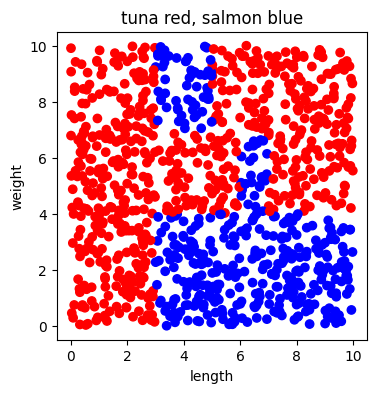

In [105]:
plt.figure(figsize=(4,4))
plt.scatter(df.length, df.weight, color=['red' if t=='tuna' else 'blue' for t in df.type])
plt.xlabel("length")
plt.ylabel("weight")
plt.title("tuna red, salmon blue")
plt.show()

In [106]:
df.type = df.type.apply(lambda t: 1 if t == 'salmon' else 0)
df.head()

,length,weight,type
0,8.618381,7.848030,0
1,2.522046,8.762507,0
2,2.035690,7.101971,0
3,6.695008,4.953932,1
4,9.834069,7.908453,0


In [107]:
def get_entropy(vals):
    p = np.mean(vals)
    # print(f"p = {p}")
    if p==0 or p==1:
        return 0
    return -p*np.log2(p) - (1-p)*np.log2(1-p)

In [108]:
get_entropy([0,0,0,0,0])

0

In [109]:
get_entropy([0,0,0,0,1])

np.float64(0.7219280948873623)

In [110]:
get_entropy([0,0,0,0,1,1])


np.float64(0.9182958340544896)

In [111]:
get_entropy([0,0,0,1,1,1])


np.float64(1.0)

In [112]:
def get_entropy_from_split(df, feature, val):
    left_types = df[df[feature] < val].type
    right_types = df[df[feature] >= val].type

    left_entropy = get_entropy(left_types)
    right_entropy = get_entropy(right_types)

    left_prop = len(left_types) / len(df)
    right_prop = len(right_types) / len(df)

    return left_prop*left_entropy + right_prop*right_entropy

In [113]:
curr_df = df.copy()
curr_df = curr_df[(curr_df.length > 3)
                  & (curr_df.weight > 4)
                  ]
curr_df.head()

,length,weight,type
0,8.618381,7.848030,0
3,6.695008,4.953932,1
4,9.834069,7.908453,0
5,5.825597,4.379918,0
10,4.296068,8.975219,1


In [114]:
curr_df.shape

(387, 3)

In [115]:
features = ['length', 'weight']

best_params = {'feature': None, 'val': None, 'entropy': np.inf}

for f in features:
    # curr = df[f].min()
    curr = curr_df[f].min()
    step = 0.1
    # while curr < df[f].max():
    while curr < curr_df[f].max():
        # curr_entropy = get_entropy_from_split(df, f, curr)
        curr_entropy = get_entropy_from_split(curr_df, f, curr)
        if curr_entropy < best_params['entropy']:
            best_params['feature'] = f
            best_params['val'] = curr
            best_params['entropy'] = curr_entropy
        curr += step
print(best_params)

{'feature': 'length', 'val': np.float64(7.008879131610914), 'entropy': np.float64(0.5524718527527053)}
